In [4]:
import warnings
warnings.filterwarnings("ignore")
!pip install Faker


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## IMPORT LIBRARIES FIRST

In [5]:
import pandas as pd
import numpy as np
import random
from faker import Faker

fake = Faker()

np.random.seed(42)
random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## MAKE CUSTOMERS DATASET

In [6]:
# Number of customers
num_customers = 5000

customer_ids = [
    f"CUST{i:05d}" 
    for i in range(1, num_customers + 1)
]

customers = pd.DataFrame({
    "CustomerID": customer_ids,
    
    "CustomerName": [
        fake.name() 
        for _ in range(num_customers)
    ],
    
    "Gender": np.random.choice(
        ["Male", "Female"],
        num_customers,
        p=[0.55, 0.45]
    ),
    
    "Age": np.random.randint(
        18, 65, num_customers
    ),
    
    "City": np.random.choice(
        [
            "Karachi",
            "Lahore",
            "Islamabad",
            "Rawalpindi",
            "Faisalabad",
            "Multan",
            "Peshawar",
            "Quetta"
        ],
        num_customers
    ),
    
    "Region": np.random.choice(
        [
            "Sindh",
            "Punjab",
            "Islamabad",
            "KPK",
            "Balochistan"
        ],
        num_customers
    )
})

customers.head()

,CustomerID,CustomerName,Gender,Age,City,Region
0,CUST00001,Daniel Nguyen,Male,57,Multan,Islamabad
1,CUST00002,Todd Johnson,Female,24,Islamabad,Islamabad
2,CUST00003,April Johnson,Female,49,Karachi,Balochistan
3,CUST00004,Melanie Suarez,Female,36,Rawalpindi,KPK
4,CUST00005,Laura Duke,Male,23,Islamabad,Sindh


## CHECK CUSTOMER DATASET

In [7]:
print("Total Customers:", len(customers))

print("\nMissing Values:")
print(customers.isnull().sum())

print("\nDuplicate Rows:")
print(customers.duplicated().sum())

Total Customers: 5000

Missing Values:
CustomerID      0
CustomerName    0
Gender          0
Age             0
City            0
Region          0
dtype: int64

Duplicate Rows:
0


## MAKE PRODUCT DATASET

In [8]:
products_data = [
    ("P001", "Laptop", "Electronics", 120000, 95000),
    ("P002", "Smartphone", "Electronics", 85000, 65000),
    ("P003", "Headphones", "Electronics", 8500, 5000),
    ("P004", "Smart Watch", "Electronics", 18000, 12000),
    ("P005", "Keyboard", "Accessories", 4500, 2800),
    ("P006", "Mouse", "Accessories", 2500, 1500),
    ("P007", "Monitor", "Electronics", 45000, 32000),
    ("P008", "USB Cable", "Accessories", 1200, 600),
    ("P009", "Backpack", "Fashion", 5500, 3200),
    ("P010", "Shoes", "Fashion", 9000, 5500),
    ("P011", "T-Shirt", "Fashion", 2500, 1400),
    ("P012", "Jeans", "Fashion", 4500, 2700),
    ("P013", "Coffee Maker", "Home Appliances", 15000, 10000),
    ("P014", "Air Fryer", "Home Appliances", 22000, 15000),
    ("P015", "Blender", "Home Appliances", 12000, 8000),
    ("P016", "Vacuum Cleaner", "Home Appliances", 28000, 19000),
    ("P017", "Office Chair", "Furniture", 32000, 22000),
    ("P018", "Desk", "Furniture", 25000, 17000),
    ("P019", "Table Lamp", "Furniture", 5000, 2800),
    ("P020", "Bookshelf", "Furniture", 18000, 12000)
]

products = pd.DataFrame(
    products_data,
    columns=[
        "ProductID",
        "ProductName",
        "Category",
        "UnitPrice",
        "UnitCost"
    ]
)

products.head()

,ProductID,ProductName,Category,UnitPrice,UnitCost
0,P001,Laptop,Electronics,120000,95000
1,P002,Smartphone,Electronics,85000,65000
2,P003,Headphones,Electronics,8500,5000
3,P004,Smart Watch,Electronics,18000,12000
4,P005,Keyboard,Accessories,4500,2800


## CHECK PRODUCT DATASET

In [9]:
print("Total Products:", len(products))

print("\nCategories:")
print(products["Category"].unique())

print("\nMissing Values:")
print(products.isnull().sum())

Total Products: 20

Categories:
<ArrowStringArray>
['Electronics', 'Accessories', 'Fashion', 'Home Appliances', 'Furniture']
Length: 5, dtype: str

Missing Values:
ProductID      0
ProductName    0
Category       0
UnitPrice      0
UnitCost       0
dtype: int64


## Generate Orders

In [10]:
num_orders = 20000

orders = pd.DataFrame({
    "OrderID": [
        f"ORD{i:06d}" 
        for i in range(1, num_orders + 1)
    ],
    
    "OrderDate": pd.to_datetime(
        np.random.choice(
            pd.date_range(
                "2024-01-01",
                "2025-12-31"
            ),
            num_orders
        )
    ),
    
    "CustomerID": np.random.choice(
        customers["CustomerID"],
        num_orders
    ),
    
    "ProductID": np.random.choice(
        products["ProductID"],
        num_orders
    ),
    
    "Quantity": np.random.randint(
        1, 6, num_orders
    ),
    
    "Discount": np.random.choice(
        [0, 0.05, 0.10, 0.15, 0.20],
        num_orders,
        p=[0.35, 0.25, 0.20, 0.15, 0.05]
    ),
    
    "PaymentMethod": np.random.choice(
        [
            "Cash",
            "Credit Card",
            "Debit Card",
            "Bank Transfer",
            "JazzCash"
        ],
        num_orders
    ),
    
    "OrderStatus": np.random.choice(
        [
            "Completed",
            "Cancelled",
            "Returned",
            "Pending"
        ],
        num_orders,
        p=[0.82, 0.07, 0.06, 0.05]
    )
})

orders.head()

,OrderID,OrderDate,CustomerID,ProductID,Quantity,Discount,PaymentMethod,OrderStatus
0,ORD000001,2025-04-18,CUST01189,P016,1,0.00,Cash,Completed
1,ORD000002,2025-04-29,CUST00409,P002,5,0.00,Debit Card,Completed
2,ORD000003,2024-01-13,CUST02486,P013,1,0.00,Credit Card,Completed
3,ORD000004,2024-06-01,CUST00797,P004,1,0.20,Cash,Completed
4,ORD000005,2024-08-26,CUST00861,P005,4,0.15,Cash,Completed


## Add Product Information

In [11]:
orders = orders.merge(
    products,
    on="ProductID",
    how="left"
)

orders.head()

,OrderID,OrderDate,CustomerID,ProductID,Quantity,Discount,PaymentMethod,OrderStatus,ProductName,Category,UnitPrice,UnitCost
0,ORD000001,2025-04-18,CUST01189,P016,1,0.00,Cash,Completed,Vacuum Cleaner,Home Appliances,28000,19000
1,ORD000002,2025-04-29,CUST00409,P002,5,0.00,Debit Card,Completed,Smartphone,Electronics,85000,65000
2,ORD000003,2024-01-13,CUST02486,P013,1,0.00,Credit Card,Completed,Coffee Maker,Home Appliances,15000,10000
3,ORD000004,2024-06-01,CUST00797,P004,1,0.20,Cash,Completed,Smart Watch,Electronics,18000,12000
4,ORD000005,2024-08-26,CUST00861,P005,4,0.15,Cash,Completed,Keyboard,Accessories,4500,2800


## Calculate Sales

In [12]:
orders["GrossSales"] = (
    orders["Quantity"] *
    orders["UnitPrice"]
)

orders["DiscountAmount"] = (
    orders["GrossSales"] *
    orders["Discount"]
)

orders["Sales"] = (
    orders["GrossSales"] -
    orders["DiscountAmount"]
)

orders["Cost"] = (
    orders["Quantity"] *
    orders["UnitCost"]
)

orders["Profit"] = (
    orders["Sales"] -
    orders["Cost"]
)

orders.head()

,OrderID,OrderDate,CustomerID,ProductID,Quantity,Discount,PaymentMethod,OrderStatus,ProductName,Category,UnitPrice,UnitCost,GrossSales,DiscountAmount,Sales,Cost,Profit
0,ORD000001,2025-04-18,CUST01189,P016,1,0.00,Cash,Completed,Vacuum Cleaner,Home Appliances,28000,19000,28000,0.0,28000.0,19000,9000.0
1,ORD000002,2025-04-29,CUST00409,P002,5,0.00,Debit Card,Completed,Smartphone,Electronics,85000,65000,425000,0.0,425000.0,325000,100000.0
2,ORD000003,2024-01-13,CUST02486,P013,1,0.00,Credit Card,Completed,Coffee Maker,Home Appliances,15000,10000,15000,0.0,15000.0,10000,5000.0
3,ORD000004,2024-06-01,CUST00797,P004,1,0.20,Cash,Completed,Smart Watch,Electronics,18000,12000,18000,3600.0,14400.0,12000,2400.0
4,ORD000005,2024-08-26,CUST00861,P005,4,0.15,Cash,Completed,Keyboard,Accessories,4500,2800,18000,2700.0,15300.0,11200,4100.0


## Add Customer Information

In [13]:
orders = orders.merge(
    customers,
    on="CustomerID",
    how="left"
)

orders.head()

,OrderID,OrderDate,CustomerID,ProductID,Quantity,Discount,PaymentMethod,OrderStatus,ProductName,Category,...,GrossSales,DiscountAmount,Sales,Cost,Profit,CustomerName,Gender,Age,City,Region
0,ORD000001,2025-04-18,CUST01189,P016,1,0.00,Cash,Completed,Vacuum Cleaner,Home Appliances,...,28000,0.0,28000.0,19000,9000.0,Brooke Nichols,Male,40,Karachi,Sindh
1,ORD000002,2025-04-29,CUST00409,P002,5,0.00,Debit Card,Completed,Smartphone,Electronics,...,425000,0.0,425000.0,325000,100000.0,Vanessa Thompson,Female,59,Lahore,Balochistan
2,ORD000003,2024-01-13,CUST02486,P013,1,0.00,Credit Card,Completed,Coffee Maker,Home Appliances,...,15000,0.0,15000.0,10000,5000.0,Blake Lynch,Female,54,Rawalpindi,KPK
3,ORD000004,2024-06-01,CUST00797,P004,1,0.20,Cash,Completed,Smart Watch,Electronics,...,18000,3600.0,14400.0,12000,2400.0,Matthew Martin,Female,56,Faisalabad,KPK
4,ORD000005,2024-08-26,CUST00861,P005,4,0.15,Cash,Completed,Keyboard,Accessories,...,18000,2700.0,15300.0,11200,4100.0,Judy Robles,Female,51,Karachi,Punjab


## Final Column Order

In [14]:
orders = orders[
    [
        "OrderID",
        "OrderDate",
        "CustomerID",
        "CustomerName",
        "Gender",
        "Age",
        "City",
        "Region",
        "ProductID",
        "ProductName",
        "Category",
        "Quantity",
        "UnitPrice",
        "Discount",
        "GrossSales",
        "DiscountAmount",
        "Sales",
        "Cost",
        "Profit",
        "PaymentMethod",
        "OrderStatus"
    ]
]

orders.head()

,OrderID,OrderDate,CustomerID,CustomerName,Gender,Age,City,Region,ProductID,ProductName,...,Quantity,UnitPrice,Discount,GrossSales,DiscountAmount,Sales,Cost,Profit,PaymentMethod,OrderStatus
0,ORD000001,2025-04-18,CUST01189,Brooke Nichols,Male,40,Karachi,Sindh,P016,Vacuum Cleaner,...,1,28000,0.00,28000,0.0,28000.0,19000,9000.0,Cash,Completed
1,ORD000002,2025-04-29,CUST00409,Vanessa Thompson,Female,59,Lahore,Balochistan,P002,Smartphone,...,5,85000,0.00,425000,0.0,425000.0,325000,100000.0,Debit Card,Completed
2,ORD000003,2024-01-13,CUST02486,Blake Lynch,Female,54,Rawalpindi,KPK,P013,Coffee Maker,...,1,15000,0.00,15000,0.0,15000.0,10000,5000.0,Credit Card,Completed
3,ORD000004,2024-06-01,CUST00797,Matthew Martin,Female,56,Faisalabad,KPK,P004,Smart Watch,...,1,18000,0.20,18000,3600.0,14400.0,12000,2400.0,Cash,Completed
4,ORD000005,2024-08-26,CUST00861,Judy Robles,Female,51,Karachi,Punjab,P005,Keyboard,...,4,4500,0.15,18000,2700.0,15300.0,11200,4100.0,Cash,Completed


## Dataset Information

In [15]:
print("Rows:", orders.shape[0])
print("Columns:", orders.shape[1])

print("\nColumn Names:")
print(orders.columns.tolist())

print("\nData Types:")
print(orders.dtypes)

Rows: 20000
Columns: 21

Column Names:
['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'Gender', 'Age', 'City', 'Region', 'ProductID', 'ProductName', 'Category', 'Quantity', 'UnitPrice', 'Discount', 'GrossSales', 'DiscountAmount', 'Sales', 'Cost', 'Profit', 'PaymentMethod', 'OrderStatus']

Data Types:
OrderID                      str
OrderDate         datetime64[us]
CustomerID                   str
CustomerName                 str
Gender                       str
Age                        int32
City                         str
Region                       str
ProductID                    str
ProductName                  str
Category                     str
Quantity                   int32
UnitPrice                  int64
Discount                 float64
GrossSales                 int64
DiscountAmount           float64
Sales                    float64
Cost                       int64
Profit                   float64
PaymentMethod                str
OrderStatus                  s

## Missing Values

In [16]:
missing_values = orders.isnull().sum()

print(missing_values)

OrderID           0
OrderDate         0
CustomerID        0
CustomerName      0
Gender            0
Age               0
City              0
Region            0
ProductID         0
ProductName       0
Category          0
Quantity          0
UnitPrice         0
Discount          0
GrossSales        0
DiscountAmount    0
Sales             0
Cost              0
Profit            0
PaymentMethod     0
OrderStatus       0
dtype: int64


## Duplicate Check

In [17]:
duplicate_count = orders.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


## Basic Business Summary

In [18]:
total_sales = orders["Sales"].sum()
total_profit = orders["Profit"].sum()
total_orders = orders["OrderID"].nunique()
total_customers = orders["CustomerID"].nunique()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)

Total Sales: 1297619665.0
Total Profit: 302580065.0
Total Orders: 20000
Total Customers: 4923


## Sales by Category

In [19]:
category_sales = (
    orders.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Electronics        774735550.0
Furniture          224800550.0
Home Appliances    214778350.0
Fashion             60540625.0
Accessories         22764590.0
Name: Sales, dtype: float64

## Top 10 Products

In [20]:
top_products = (
    orders.groupby("ProductName")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

ProductName
Laptop            330450000.0
Smartphone        242607000.0
Monitor           125831250.0
Office Chair       90984000.0
Vacuum Cleaner     79797200.0
Desk               68482500.0
Air Fryer          60599000.0
Smart Watch        52480800.0
Bookshelf          51625800.0
Coffee Maker       42690750.0
Name: Sales, dtype: float64

## Monthly Sales

In [21]:
monthly_sales = (
    orders.groupby(
        orders["OrderDate"].dt.to_period("M")
    )["Sales"]
    .sum()
)

monthly_sales

OrderDate
2024-01    55534100.0
2024-02    51663320.0
2024-03    58374320.0
2024-04    51933700.0
2024-05    55192070.0
2024-06    52641215.0
2024-07    55000080.0
2024-08    55490395.0
2024-09    61063250.0
2024-10    51442995.0
2024-11    51664280.0
2024-12    56466375.0
2025-01    56954540.0
2025-02    44604465.0
2025-03    51339485.0
2025-04    50870885.0
2025-05    55325025.0
2025-06    54741795.0
2025-07    57730170.0
2025-08    57761225.0
2025-09    50964180.0
2025-10    55900415.0
2025-11    52722540.0
2025-12    52238840.0
Freq: M, Name: Sales, dtype: float64

## Save Files

In [22]:
orders.to_csv(
    "ecommerce_orders.csv",
    index=False
)

customers.to_csv(
    "customers.csv",
    index=False
)

products.to_csv(
    "products.csv",
    index=False
)

print("All CSV files saved successfully!")

All CSV files saved successfully!


## Import + Load Dataset

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ecommerce_orders.csv")

df["OrderDate"] = pd.to_datetime(df["OrderDate"])

df.head()

,OrderID,OrderDate,CustomerID,CustomerName,Gender,Age,City,Region,ProductID,ProductName,...,Quantity,UnitPrice,Discount,GrossSales,DiscountAmount,Sales,Cost,Profit,PaymentMethod,OrderStatus
0,ORD000001,2025-04-18,CUST01189,Brooke Nichols,Male,40,Karachi,Sindh,P016,Vacuum Cleaner,...,1,28000,0.00,28000,0.0,28000.0,19000,9000.0,Cash,Completed
1,ORD000002,2025-04-29,CUST00409,Vanessa Thompson,Female,59,Lahore,Balochistan,P002,Smartphone,...,5,85000,0.00,425000,0.0,425000.0,325000,100000.0,Debit Card,Completed
2,ORD000003,2024-01-13,CUST02486,Blake Lynch,Female,54,Rawalpindi,KPK,P013,Coffee Maker,...,1,15000,0.00,15000,0.0,15000.0,10000,5000.0,Credit Card,Completed
3,ORD000004,2024-06-01,CUST00797,Matthew Martin,Female,56,Faisalabad,KPK,P004,Smart Watch,...,1,18000,0.20,18000,3600.0,14400.0,12000,2400.0,Cash,Completed
4,ORD000005,2024-08-26,CUST00861,Judy Robles,Female,51,Karachi,Punjab,P005,Keyboard,...,4,4500,0.15,18000,2700.0,15300.0,11200,4100.0,Cash,Completed


# PYTHON EDA 

## Monthly Sales Trend 📈

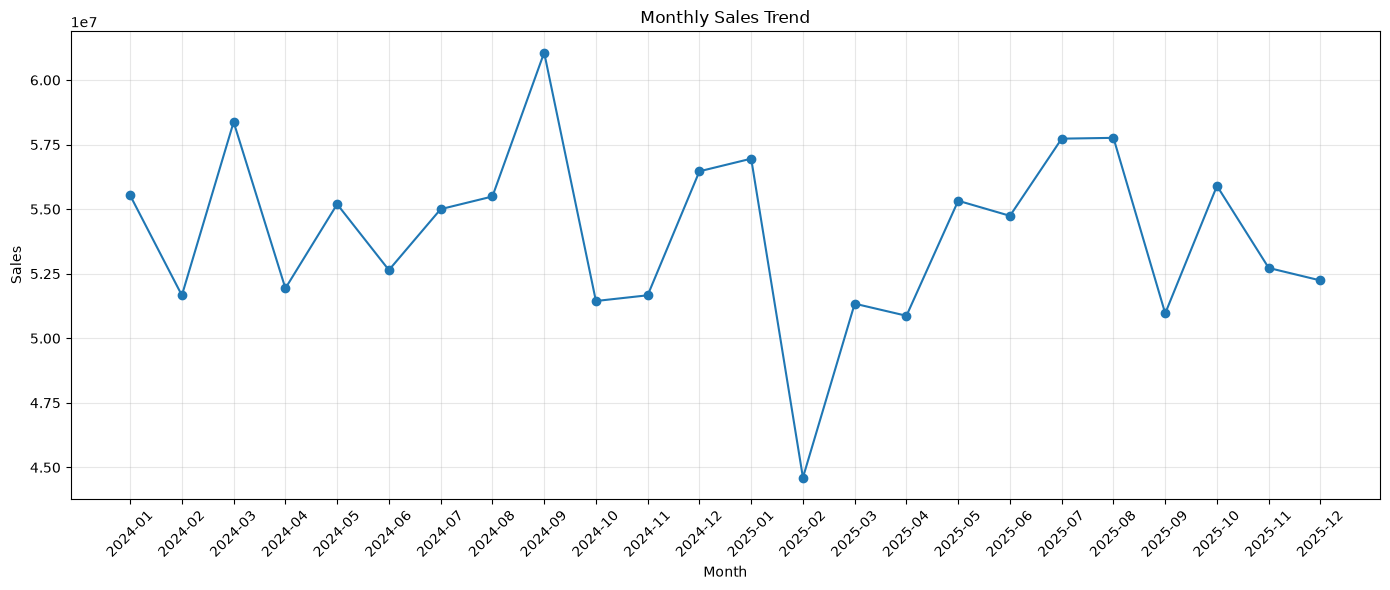

In [24]:
monthly_sales = (
    df.groupby(df["OrderDate"].dt.to_period("M"))["Sales"]
    .sum()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

 ## Insight: Sales kis month/year mein increase ya decrease hui.

## Sales by Category 📊

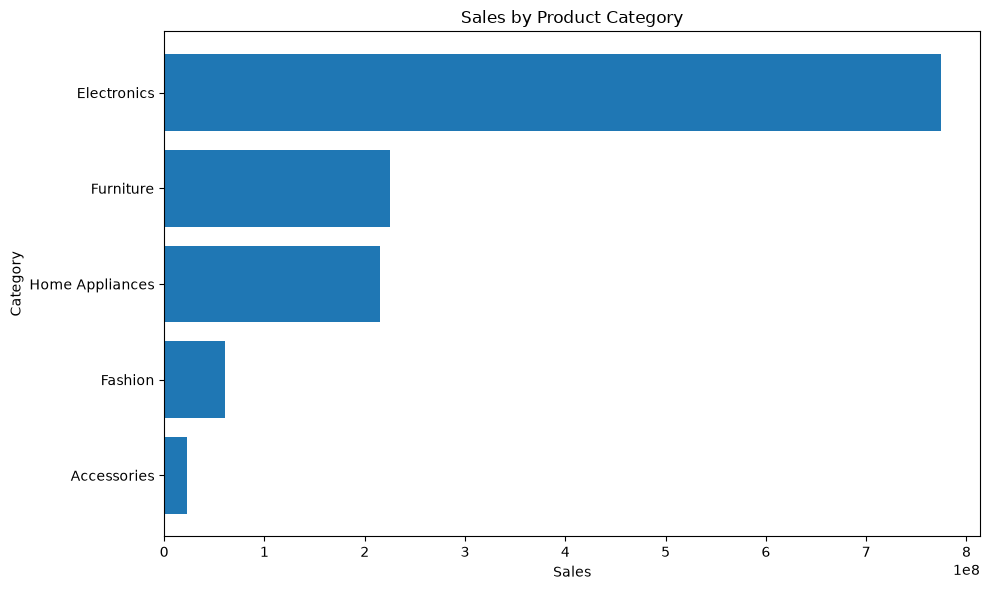

In [25]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    category_sales.index,
    category_sales.values
)

plt.title("Sales by Product Category")
plt.xlabel("Sales")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

## Insight: Kaunsi category sabse zyada revenue generate kar rahi hai.

## Top 10 Products 🔝

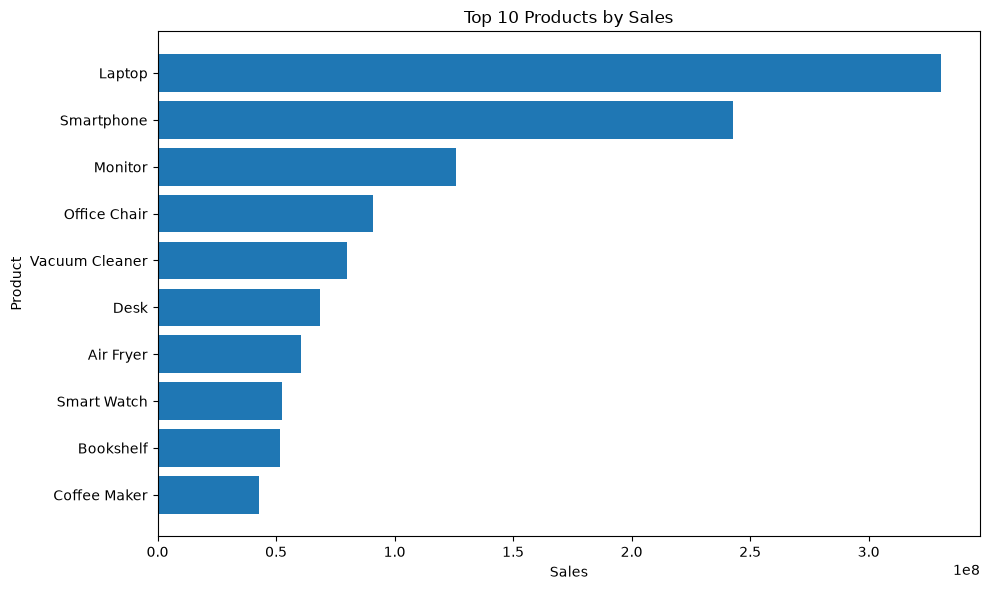

In [26]:
top_products = (
    df.groupby("ProductName")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products.index,
    top_products.values
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

## Insight: Business ke highest-performing products.

## Sales by Region 🌍

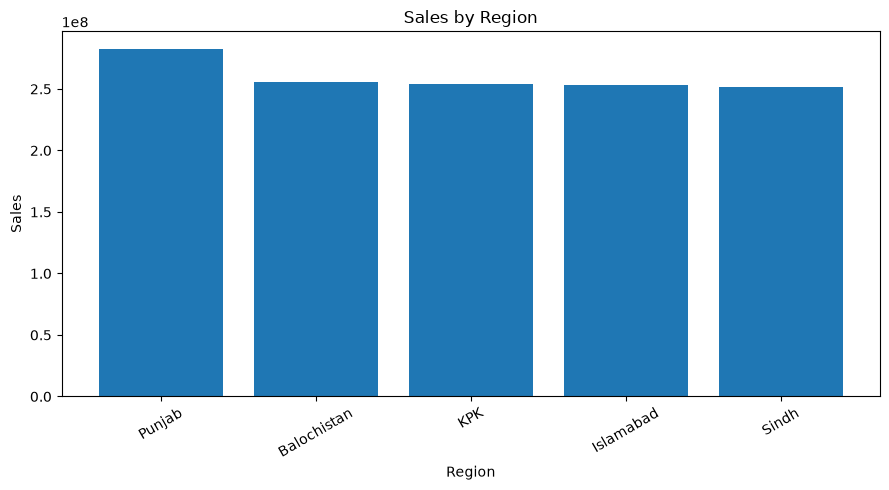

In [27]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

plt.bar(
    region_sales.index,
    region_sales.values
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Insight: Kaunsa region strongest market hai.

## Profit vs Sales 💰

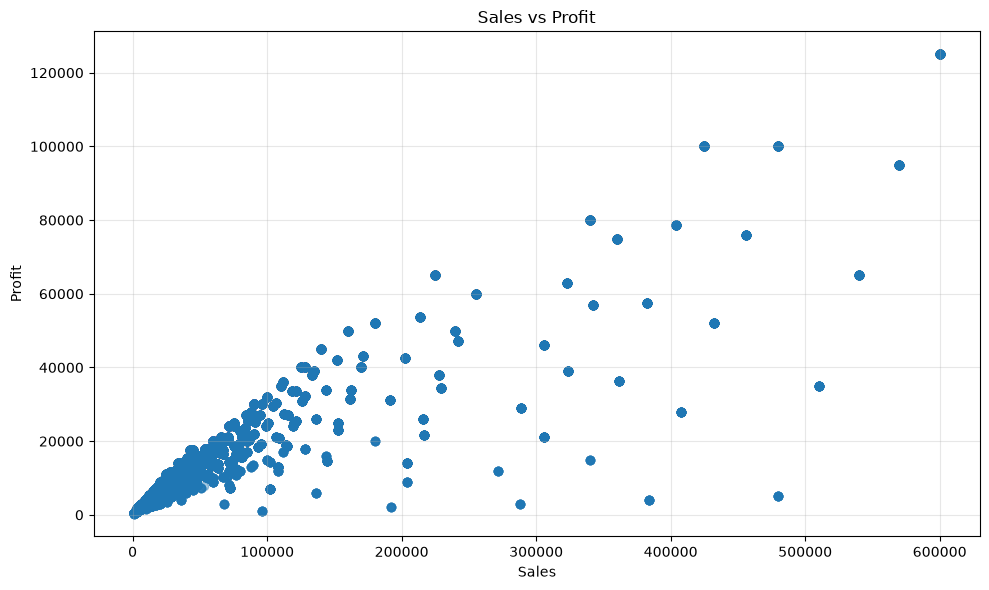

In [28]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Sales"],
    df["Profit"],
    alpha=0.4
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Insight: High sales ka matlab hamesha high profit nahi hota.

## Order Status Distribution

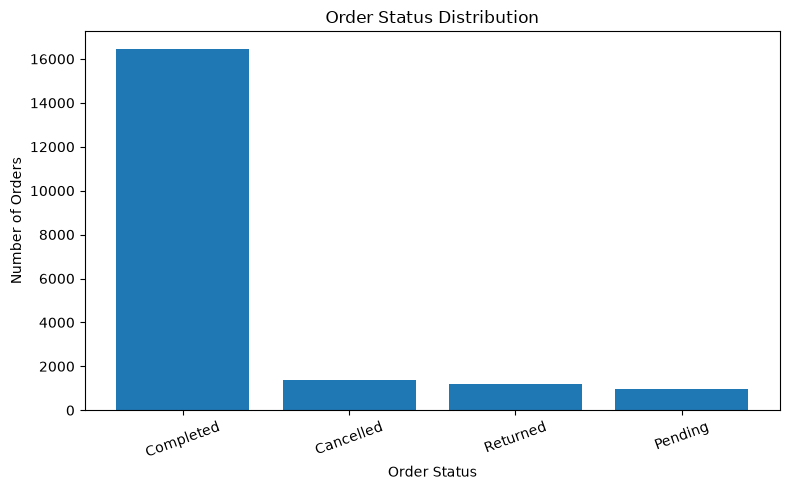

In [29]:
status_counts = df["OrderStatus"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    status_counts.index,
    status_counts.values
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## Insight: Completed, Cancelled, Returned aur Pending orders ka comparison.